In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
def phi(x):
    return norm.pdf(x)

def G(x):
    return 1-norm.cdf(x)

def M(x):
    return phi(x)/G(x)


def v1(x):
    return M(x)
    
def v2(x):
    return 1/(M(x)-x)

def v3(x):
    return (2*M(x) - 2*x)/(x**2 + 1 - x*M(x))

def vartheta_v1(h):
    x = v1(h)
    return G(h) / G(x)

def vartheta_v2(h):
    x = v2(h)
    return (phi(h) - h*G(h)) / ((x-h)*G(x))

def vartheta_v3(h):
    x = v3(h)
    return ((1 + h**2)*G(h) - h*phi(h)) / ((x-h)**2*G(x))



def f1(x, delta, c = np.e):
    return x + (v1(x) - x)*G(v1(x))*(vartheta_v1(x)/delta)

def f2(x, delta, c = np.e**2/2):
    return x + (v2(x) - x)*(G(v2(x))*(vartheta_v2(x)/delta))**(1/2)

def f3(x, delta, c = 2*np.e**3/9):
    return x + (v3(x) - x)*(G(v3(x))*(vartheta_v3(x)/delta))**(1/3)

def A(x, delta):
    return (np.log(1/delta) + x**2 / 2)/x

def f_subg(delta):
    return np.sqrt(2 *np.log(1/delta))

def g(delta):
    return norm.ppf(1-delta)

# Vanilla plot

/var/folders/6l/5fsz8v5s73d453t40st4csy80000gn/T/ipykernel_3335/3763499003.py:44: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2)/x


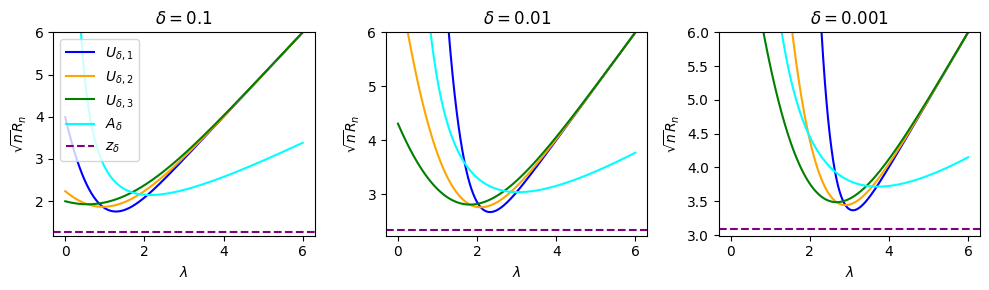

In [6]:
# deltas = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005, 0.00001]
# fig, axes = plt.subplots(3, 3, figsize=(10, 10))

deltas = [0.1, 0.01, 0.001]
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='orange')
    
    y = f3(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')
    
    y = A(x, delta)
    ax.plot(x, y, label=fr"$A_{{\delta}}$", color='cyan')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='purple', linestyle='--')

    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend()

plt.tight_layout()
plt.savefig(f"bounds_plot.png", dpi=300)
plt.show()

# Post-hoc inference

vline 2 no red line

/var/folders/6l/5fsz8v5s73d453t40st4csy80000gn/T/ipykernel_3335/3763499003.py:44: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2)/x


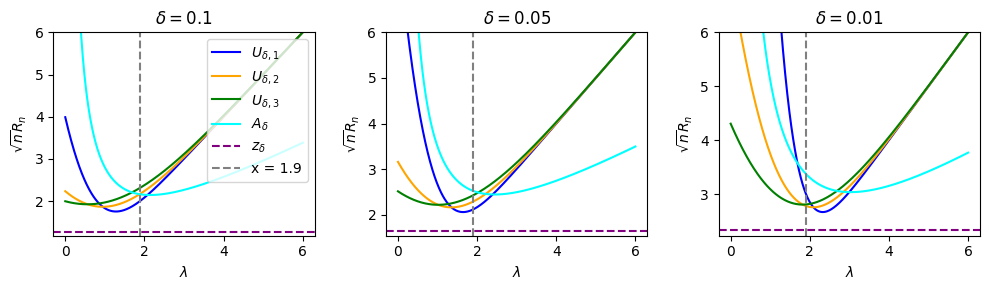

In [8]:
deltas = [0.1, 0.05, 0.01]
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='orange')
    
    y = f3(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')
    
    y = A(x, delta)
    ax.plot(x, y, label=fr"$A_{{\delta}}$", color='cyan')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='purple', linestyle='--')

    vline = 1.9
    ax.axvline(vline, label=fr"x = {vline}", color='gray', linestyle='--')

    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"bounds_plot_vline{vline}.png", dpi=300)
plt.show()

vline 2

/var/folders/6l/5fsz8v5s73d453t40st4csy80000gn/T/ipykernel_60823/3763499003.py:44: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2)/x


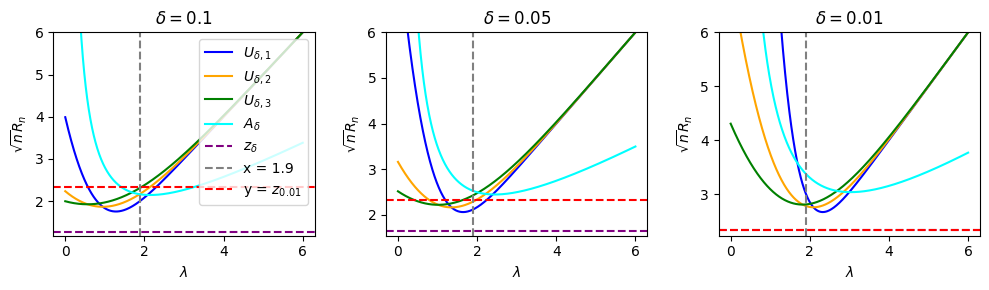

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



deltas = [0.1, 0.05, 0.01]
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='orange')
    
    y = f3(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')
    
    y = A(x, delta)
    ax.plot(x, y, label=fr"$A_{{\delta}}$", color='cyan')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='purple', linestyle='--')

    vline = 1.9
    ax.axvline(vline, label=fr"x = {vline}", color='gray', linestyle='--')
    ax.axhline(g(0.01), label=fr"y = $z_{{0.01}}$", color='red', linestyle='--')
    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right')

plt.tight_layout()
#plt.savefig(f"bounds_plot_vline{vline}.png", dpi=300)
plt.show()

# Multiple testing

vline 3.3

/var/folders/6l/5fsz8v5s73d453t40st4csy80000gn/T/ipykernel_60823/2270505638.py:31: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2)/x


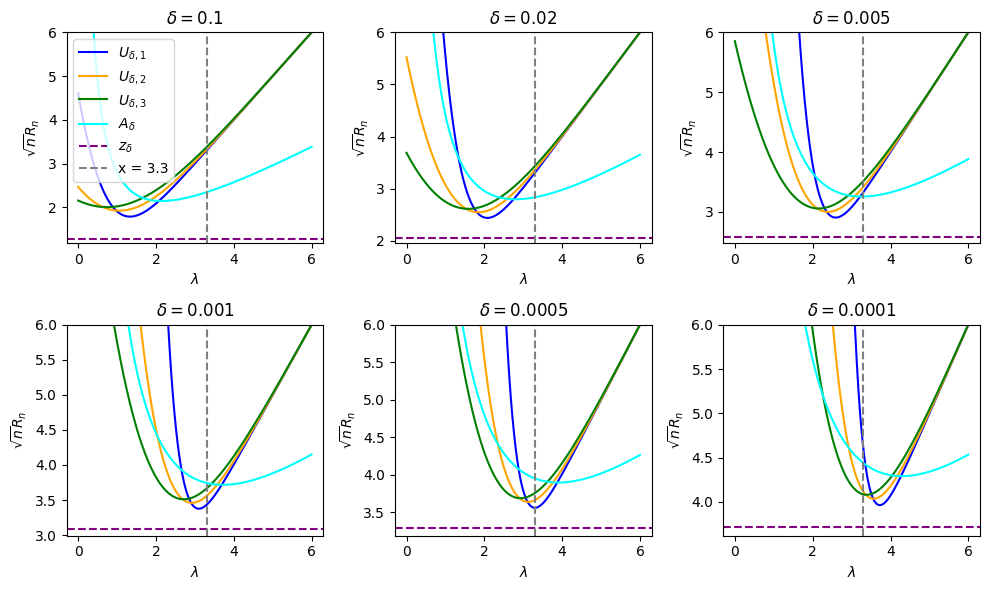

In [6]:
import numpy as np
import matplotlib.pyplot as plt

deltas = [0.1, 0.02, 0.005, 0.001, 0.0005, 0.0001]
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# deltas = [0.1, 0.05, 0.01]
# fig, axes = plt.subplots(1, 3, figsize=(10, 6))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='orange')
    
    y = f3(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')
    
    y = A(x, delta)
    ax.plot(x, y, label=fr"$A_{{\delta}}$", color='cyan')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='purple', linestyle='--')

    vline = 3.3
    ax.axvline(vline, label=fr"x = {vline}", color='gray', linestyle='--')
    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend()

plt.tight_layout()
plt.savefig(f"bounds_plot_vline{vline}.png", dpi=300)
plt.show()

vline 2.6

/var/folders/6l/5fsz8v5s73d453t40st4csy80000gn/T/ipykernel_3335/3763499003.py:44: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2)/x


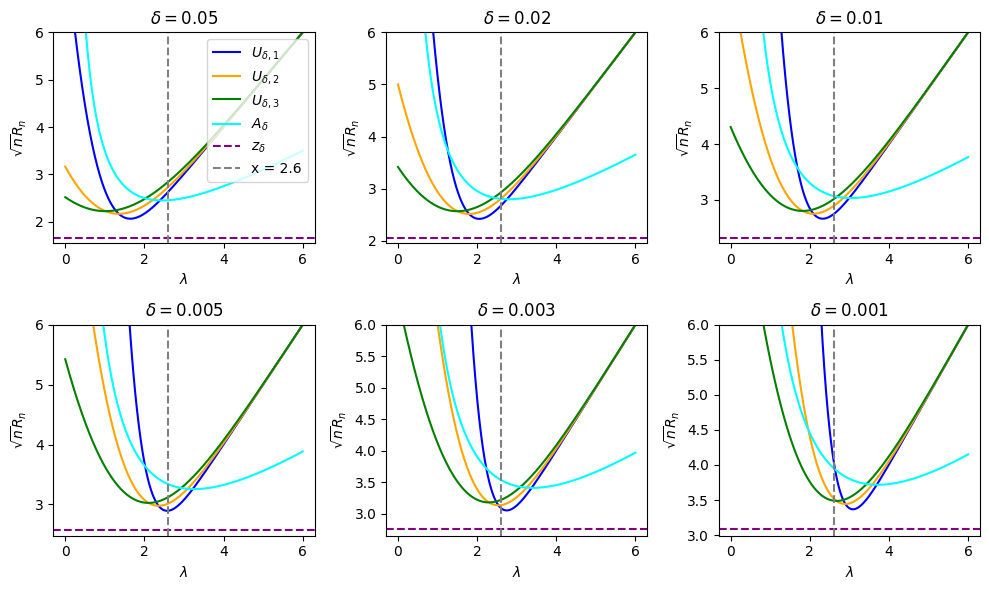

In [9]:
deltas = [0.05, 0.02, 0.01, 0.005, 0.003, 0.001]
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# deltas = [0.1, 0.05, 0.01]
# fig, axes = plt.subplots(1, 3, figsize=(10, 6))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='orange')
    
    y = f3(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')
    
    y = A(x, delta)
    ax.plot(x, y, label=fr"$A_{{\delta}}$", color='cyan')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='purple', linestyle='--')

    vline = 2.6
    ax.axvline(vline, label=fr"x = {vline}", color='gray', linestyle='--')
    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"bounds_plot_vline{vline}.png", dpi=300)
plt.show()

vline 2.6 red line

/var/folders/6l/5fsz8v5s73d453t40st4csy80000gn/T/ipykernel_60823/2270505638.py:31: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2)/x


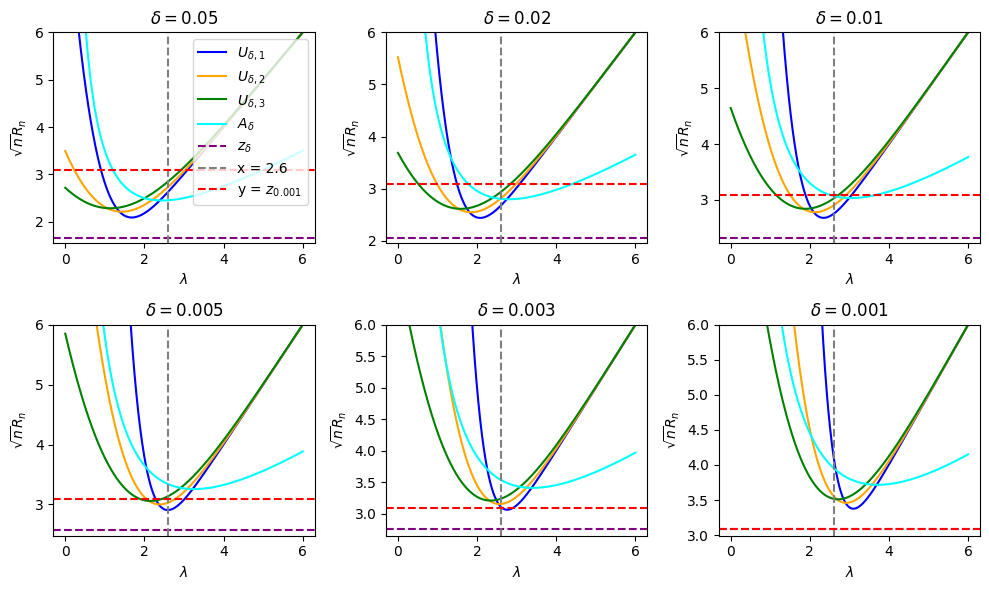

In [ ]:
deltas = [0.05, 0.02, 0.01, 0.005, 0.003, 0.001]
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# deltas = [0.1, 0.05, 0.01]
# fig, axes = plt.subplots(1, 3, figsize=(10, 6))

axes = axes.flatten()
x = np.linspace(0, 6, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 1}}$", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 2}}$", color='orange')
    
    y = f3(x, delta)
    ax.plot(x, y, label=fr"$U_{{\delta, 3}}$", color='green')
    
    y = A(x, delta)
    ax.plot(x, y, label=fr"$A_{{\delta}}$", color='cyan')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label=fr"$z_{{\delta}}$", color='purple', linestyle='--')

    vline = 2.6
    ax.axvline(vline, label=fr"x = {vline}", color='gray', linestyle='--')
    ax.axhline(g(0.001), label=fr"y = $z_{{0.001}}$", color='red', linestyle='--')
    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)
    ax.set_ylim(g(delta)-.1, 6)

axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"bounds_plot_vline{vline}.png", dpi=300)
plt.show()